# 1D Poisson with P1 finite elements

$-u'' = \pi^2 \sin(\pi x)$ on $(0,1)$, with $u(0)=u(1)=0$.

Exact solution: $u = \sin(\pi x)$.

In [1]:
import numpy as np
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve, cg
import matplotlib.pyplot as plt

f        = lambda x: np.pi**2 * np.sin(np.pi*x)   # source term
u_exact  = lambda x: np.sin(np.pi*x)              # exact solution
du_exact = lambda x: np.pi * np.cos(np.pi*x)      # its derivative

## 1. Weak form

Multiply by a test function $v$ with $v(0)=v(1)=0$ and integrate by parts:

$$\int_0^1 u'v'\,dx = \int_0^1 fv\,dx$$

Only one derivative now, so straight lines are allowed.

## 2. Quadrature

Needed for $\int f N_i$. 2-point Gauss is exact up to cubics; its error is $O(h^5)$,
far below the $O(h^2)$ we want to measure.

In [2]:
def gauss(x0, x1, k):
    """k-point Gauss points and weights, mapped onto [x0, x1]."""
    p, w = np.polynomial.legendre.leggauss(k)
    return 0.5*(x0+x1) + 0.5*(x1-x0)*p, 0.5*(x1-x0)*w

## 3. Assembly

Local stiffness on an element of length $h$ is $\frac{1}{h}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}$,
because the two hat functions have slopes $\mp 1/h$.

Each element adds its 2x2 block into the global matrix at its node numbers.
Collect `(row, col, value)` triplets; COO sums duplicates, and that sum **is** the assembly.

Boundary conditions: delete row/col 0 and n. Those values are known, so they are not unknowns.

In [3]:
def assemble(n, k=2):
    """Return nodes and the reduced system A u = b (boundary rows/cols removed)."""
    nodes = np.linspace(0, 1, n+1)
    h = 1/n
    rows, cols, vals, b = [], [], [], np.zeros(n+1)

    for e in range(n):
        x0, x1 = nodes[e], nodes[e+1]
        Ke = (1/h) * np.array([[1., -1.], [-1., 1.]])

        xq, wq = gauss(x0, x1, k)
        N = [(x1-xq)/h, (xq-x0)/h]                  # the two hat functions
        be = [np.sum(wq*f(xq)*N[0]), np.sum(wq*f(xq)*N[1])]

        for i in range(2):                          # scatter-add
            b[e+i] += be[i]
            for j in range(2):
                rows.append(e+i)
                cols.append(e+j)
                vals.append(Ke[i, j])

    A = coo_matrix((vals, (rows, cols)), shape=(n+1, n+1)).tocsr()
    interior = np.arange(1, n)
    return nodes, A[interior][:, interior], b[interior]


def solve(n, k=2):
    """Solve and return nodes and nodal values u_h."""
    nodes, A, b = assemble(n, k)
    u = np.zeros(n+1)
    u[1:n] = spsolve(A.tocsc(), b)
    return nodes, u

## 4. Error

Integrate over each element. Do **not** compare at the nodes: in 1D the P1 solution is
exact at the nodes, so that would measure nothing.

- L2: $\sqrt{\int (u-u_h)^2}$, expected rate 2
- H1: $\sqrt{\int (u'-u_h')^2}$, expected rate 1

In [4]:
def errors(nodes, u, k=5):
    """L2 and H1 error. u_h is linear on each element, so u_h' is a constant slope."""
    h = nodes[1] - nodes[0]
    l2 = h1 = 0.0

    for e in range(len(nodes)-1):
        x0, x1 = nodes[e], nodes[e+1]
        xq, wq = gauss(x0, x1, k)

        uh    = u[e]*(x1-xq)/h + u[e+1]*(xq-x0)/h
        slope = (u[e+1] - u[e]) / h

        l2 += np.sum(wq * (u_exact(xq) - uh)**2)
        h1 += np.sum(wq * (du_exact(xq) - slope)**2)

    return np.sqrt(l2), np.sqrt(h1)

## 5. Convergence

Rate $= \log_2(\text{error}_\text{coarse} / \text{error}_\text{fine})$.

In [5]:
data, prev = [], None
print(f"{'n':>5}{'L2':>12}{'rate':>7}{'H1':>12}{'rate':>7}")

for n in [10, 20, 40, 80, 160]:
    nodes, u = solve(n)
    l2, h1 = errors(nodes, u)

    r2 = f"{np.log2(prev[0]/l2):.2f}" if prev else "-"
    r1 = f"{np.log2(prev[1]/h1):.2f}" if prev else "-"
    print(f"{n:>5}{l2:>12.3e}{r2:>7}{h1:>12.3e}{r1:>7}")

    data.append((1/n, l2, h1))
    prev = (l2, h1)

    n          L2   rate          H1   rate
   10   6.353e-03      -   2.011e-01      -
   20   1.592e-03   2.00   1.007e-01   1.00
   40   3.981e-04   2.00   5.036e-02   1.00
   80   9.954e-05   2.00   2.518e-02   1.00
  160   2.489e-05   2.00   1.259e-02   1.00


Rates are **2.00** and **1.00** — exactly what P1 theory predicts.

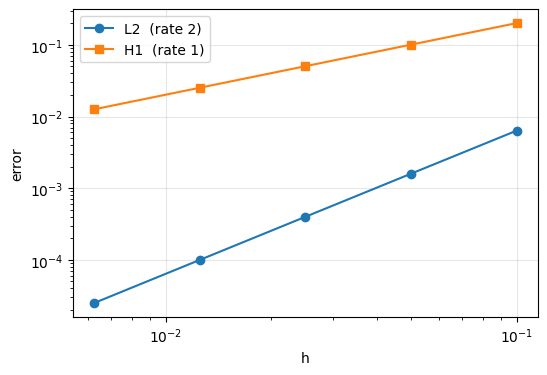

In [6]:
h, l2, h1 = np.array(data).T

plt.figure(figsize=(6, 4))
plt.loglog(h, l2, 'o-', label='L2  (rate 2)')
plt.loglog(h, h1, 's-', label='H1  (rate 1)')
plt.xlabel('h'); plt.ylabel('error')
plt.legend(); plt.grid(alpha=0.3); plt.show()

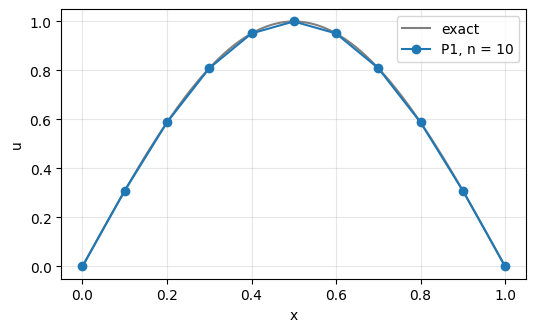

In [7]:
nodes, u = solve(10)
x = np.linspace(0, 1, 300)

plt.figure(figsize=(6, 3.5))
plt.plot(x, u_exact(x), color='gray', label='exact')
plt.plot(nodes, u, 'o-', label='P1, n = 10')
plt.xlabel('x'); plt.ylabel('u')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Optional: conjugate gradient

Condition number grows like $n^2$, so iterations should grow like $n$.

In [8]:
print(f"{'n':>6}{'iters (real b)':>16}{'iters (random b)':>18}")

for n in [10, 20, 40, 80, 160, 320]:
    _, A, b = assemble(n)
    counts = []

    for rhs in [b, np.random.default_rng(0).standard_normal(len(b))]:
        c = [0]
        cg(A, rhs, rtol=1e-10, callback=lambda _: c.__setitem__(0, c[0]+1))
        counts.append(c[0])

    print(f"{n:>6}{counts[0]:>16}{counts[1]:>18}")

     n  iters (real b)  iters (random b)
    10               1                 9
    20               1                19
    40               1                39
    80               1                79
   160               1               159
   320               3               319


**The real $b$ needs 1 iteration.** Not a bug: $f=\pi^2\sin(\pi x)$ is the first eigenfunction,
so $b$ is an eigenvector of $A$. Then $Ab$ is just a multiple of $b$, the Krylov space never
grows, and CG lands on the answer in one step.

With a random $b$ the count doubles per refinement, as predicted.